In [1]:
import torch
import torch.utils.data as tud
import torch.nn as nn
import torch.nn.functional as F

import torchvision.transforms.functional as tvf
import torchvision.datasets as tds
import torchvision.utils as tu

from tqdm import tqdm
import matplotlib.pyplot as plt

In [2]:
def onehot_label(cls: int):
    cls = torch.tensor(cls).long()
    return F.one_hot(cls, num_classes=11)

cifar_train = tds.CIFAR10(
    root='datasets',
    download=True,
    train=True,
    transform=tvf.pil_to_tensor,
    target_transform=onehot_label,
)

cifar_eval = tds.CIFAR10(
    root='datasets',
    download=True,
    train=False,
    transform=tvf.pil_to_tensor,
    target_transform=onehot_label,
)

Files already downloaded and verified
Files already downloaded and verified


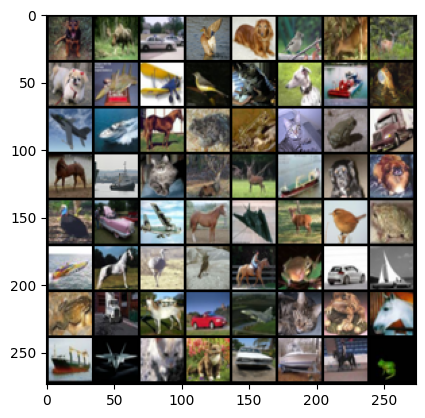

In [9]:
def random_grid(imgs, sz: int):
    samples_ix = torch.randint(low=0, high=len(imgs) - 1, size=(sz,))
    samples = imgs[samples_ix]
    grid = tu.make_grid(samples)
    return grid.permute(1, 2, 0)

tmps = torch.from_numpy(cifar_train.data)
tmps = random_grid(tmps.permute(0, 3, 1, 2), 64)
plt.imshow(tmps)

In [4]:
batchsize = 32

train_loader = tud.DataLoader(cifar_train, batch_size=batchsize, shuffle=True)
val_loader = tud.DataLoader(cifar_eval, batch_size=batchsize, shuffle=True)

In [5]:
class MyNn(nn.Module):
    def __init__(self, in_sz, out_sz, hidden_sz=128):
        super().__init__()
        self.in_sz = in_sz
        self.out_sz = out_sz
        self.lin1 = nn.Linear(in_sz, hidden_sz, bias=True)
        self.lin2 = nn.Linear(hidden_sz, hidden_sz, bias=True)
        self.lin3 = nn.Linear(hidden_sz, hidden_sz, bias=True)
        self.lin4 = nn.Linear(hidden_sz, out_sz, bias=True)

    def forward(self, x):
        x = x.flatten(start_dim=1)
        x = x.reshape(-1, self.in_sz)
        x = self.lin1(x)
        x = F.relu(x)
        x = self.lin2(x)
        x = F.relu(x)
        x = self.lin3(x)
        x = F.relu(x)
        x = self.lin4(x)
        x = F.softmax(x, dim=-1)
        return x

class MyCnn(nn.Module):
    def __init__(self, out_sz=10, ch=32):
        super().__init__()

        self.channels = ch
        self.out_sz = out_sz
        # (32x32)
        self.conv1_1 = nn.Conv2d(3, ch, kernel_size=3, stride=1, padding=1)
        self.conv1_2 = nn.Conv2d(ch, ch*2, kernel_size=3, stride=1, padding=1)

        # (16x16)
        self.conv2_1 = nn.Conv2d(ch*2, ch*2, kernel_size=3, stride=1, padding=1)
        self.conv2_2 = nn.Conv2d(ch*2, ch*4, kernel_size=3, stride=1, padding=1)
        
        # (8x8)
        self.lin1 = nn.Linear(ch*4 * 8 * 8, 128, bias=True)
        self.lin2 = nn.Linear(128, out_sz, bias=True)

    def forward(self, x):
        x = self.conv1_1(x)
        x = F.relu(x)
        x = self.conv1_2(x)
        x = F.relu(x)
        x = F.max_pool2d(x, kernel_size=2)

        x = self.conv2_1(x)
        x = F.relu(x)
        x = self.conv2_2(x)
        x = F.relu(x)
        x = F.max_pool2d(x, kernel_size=2)

        x = x.view(-1, self.channels*4 * 8 * 8)
        x = self.lin1(x)
        x = F.relu(x)
        x = self.lin2(x)
        x = F.softmax(x, dim=-1)
        return x
        

In [6]:
from torchinfo import summary
testmodel = MyCnn(out_sz=11, ch=32)
# testmodel = MyNn(3 * 32 * 32, 11, hidden_sz=512)
test = cifar_train[0][0].float()
target = cifar_train[0][1].float()
print(target, testmodel(test))
summary(testmodel, test.unsqueeze(0).shape)

tensor([0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0.]) tensor([[0.1489, 0.0369, 0.0558, 0.1917, 0.0788, 0.1777, 0.0125, 0.0461, 0.0920,
         0.1311, 0.0285]], grad_fn=<SoftmaxBackward0>)


Layer (type:depth-idx)                   Output Shape              Param #
MyCnn                                    [1, 11]                   --
├─Conv2d: 1-1                            [1, 32, 32, 32]           896
├─Conv2d: 1-2                            [1, 64, 32, 32]           18,496
├─Conv2d: 1-3                            [1, 64, 16, 16]           36,928
├─Conv2d: 1-4                            [1, 128, 16, 16]          73,856
├─Linear: 1-5                            [1, 128]                  1,048,704
├─Linear: 1-6                            [1, 11]                   1,419
Total params: 1,180,299
Trainable params: 1,180,299
Non-trainable params: 0
Total mult-adds (M): 49.27
Input size (MB): 0.01
Forward/backward pass size (MB): 1.18
Params size (MB): 4.72
Estimated Total Size (MB): 5.91

2.1061716079711914
2.0158841609954834
1.9800927639007568
1.9247816801071167
1.9389740228652954
1.9068584442138672
1.8796319961547852
1.8967422246932983
1.860167145729065
1.8640704154968262
1.8788378238677979
1.8619344234466553
1.837538480758667
1.8456727266311646
1.8321717977523804
1.8372248411178589
1.8326410055160522
1.8367778062820435
1.8289012908935547
1.8463560342788696
CPU times: user 13min 44s, sys: 593 ms, total: 13min 45s
Wall time: 1min 9s


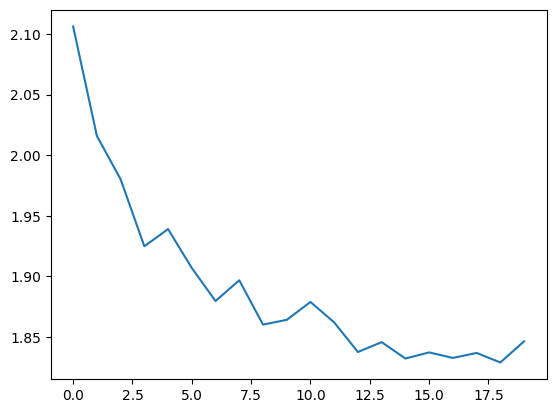

In [7]:
%%time
device='cuda'
# model = MyNn(3 * 32 * 32, 11, hidden_sz=512).to(device)
model = MyCnn(out_sz=11, ch=32).to(device)

optimizer = torch.optim.SGD(model.parameters(), lr=0.001, momentum=0.9)
lossfn = nn.CrossEntropyLoss()
epochs = 20

loss_plot = []
for epoch in range(epochs):
    for i, (images, target) in enumerate(train_loader):
        optimizer.zero_grad()
        images = images.float().to(device)
        targets = target.float().to(device)

        outs = model(images)
        loss = lossfn(outs, targets.view(-1, 11))
        loss.backward()
        optimizer.step()

    losses = []
    for i, (images, target) in enumerate(val_loader):
        with torch.no_grad():
            images = images.float().to(device)
            targets = target.float().to(device)
            outs = model(images)
            loss = lossfn(outs, targets.view(-1, 11))
            losses.append(loss)
    epoch_loss = torch.Tensor(losses).mean().item()
    print(epoch_loss)
    loss_plot.append(epoch_loss)

plt.plot(loss_plot)

In [8]:
total = len(cifar_eval)
correct = 0
with torch.no_grad():
    for image, target in cifar_eval:
        pred = model(image.float().to(device))
        if torch.allclose(pred.round().long().cpu(), target.cpu()):
            correct += 1
        
    print("{:.2f}% correct".format(100*correct/total))

69.47% correct
